<a href="https://colab.research.google.com/github/Tharindusam99/PassPro/blob/Injury-Classification-Model/Untitled23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [ ]:
from pathlib import Path
data_dir =Path(r"/content/drive/MyDrive/NetballProject/injury_dataset")

In [ ]:
img_height,img_width=224,224
batch_size=5
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 176 files belonging to 3 classes.
Using 141 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 176 files belonging to 3 classes.
Using 35 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['abrasions', 'mild_bruises', 'severe_bruise']


In [ ]:
# Create the sequential model
resnet_model = Sequential()

# Load pretrained ResNet50 model
pretrained_model = tf.keras.applications.ResNet50(include_top=False,
                          input_shape=(224, 224, 3),
                          pooling='avg',
                          weights='imagenet')

# Freeze the pretrained layers
for layer in pretrained_model.layers:
    layer.trainable = False

# Add layers to the sequential model
resnet_model.add(pretrained_model)
resnet_model.add(tf.keras.layers.Flatten())
resnet_model.add(tf.keras.layers.Dense(512, activation='relu'))
resnet_model.add(tf.keras.layers.Dense(256, activation='relu'))
resnet_model.add(tf.keras.layers.Dense(len(class_names), activation='softmax'))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
epochs=20
history = resnet_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.4500 - loss: 1.6413 - val_accuracy: 0.6857 - val_loss: 0.6186
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8634 - loss: 0.2840 - val_accuracy: 0.6286 - val_loss: 1.2228
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8520 - loss: 0.3780 - val_accuracy: 0.8286 - val_loss: 0.3893
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 1.0000 - loss: 0.0302 - val_accuracy: 0.8000 - val_loss: 0.3748
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 0.7714 - val_loss: 0.4929
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8000 - val_loss: 0.4260
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.7714 - val_loss: 0.4867
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 1.0000 - loss: 6.8831e-04 - val_accuracy: 0.8000 - val_l

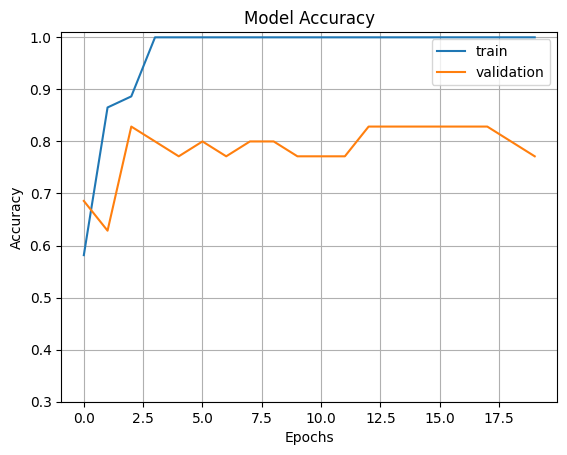

In [ ]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.30,ymax=1.01)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

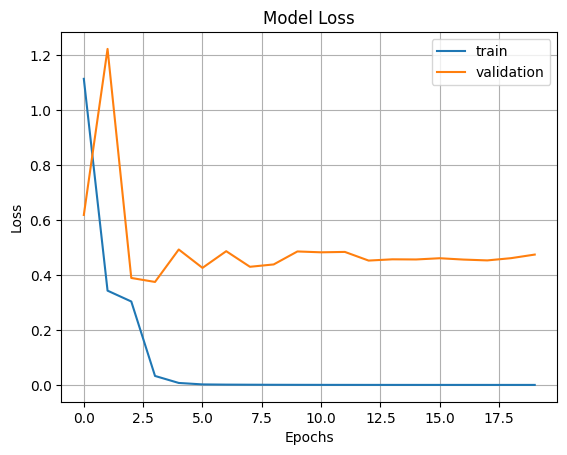

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
resnet_model.save("/content/drive/MyDrive/NetballProject/netball_injury_model.keras")

In [ ]:
model = keras.models.load_model("/content/drive/MyDrive/NetballProject/netball_injury_model.keras")

In [ ]:
predictions = []
true_values = []
for images , labels in val_ds:
  predictions.append(np.argmax(model.predict(images) , axis=1))
  true_values.append(labels)
predictions_tensor = [tf.constant(array) for array in predictions]
predictions_tensor = tf.concat(predictions_tensor , axis=0)
true_values_tensor = tf.concat(true_values , axis=0)


confusion_matrix = tf.math.confusion_matrix(labels=true_values_tensor , predictions=predictions_tensor)
confusion_matrix  = confusion_matrix.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step


In [ ]:
cm_percent = (confusion_matrix / confusion_matrix.sum(axis=1)[:, np.newaxis]) * 100
print(cm_percent)

[[92.85714286  7.14285714  0.        ]
 [35.71428571 64.28571429  0.        ]
 [14.28571429 14.28571429 71.42857143]]


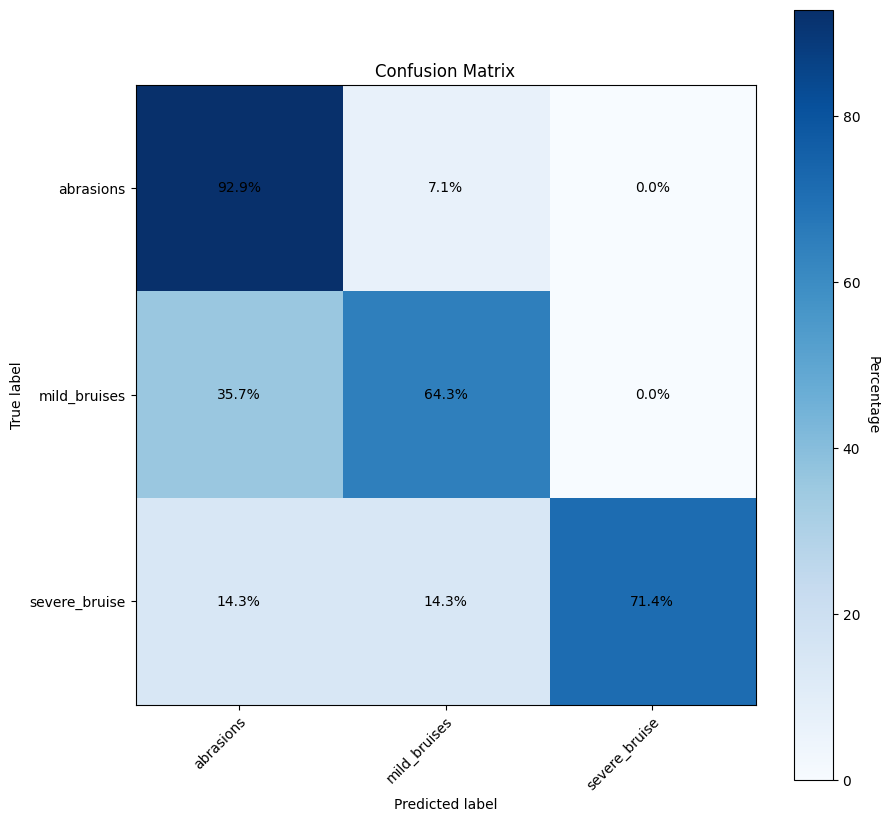

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



# Define class labels
labels = class_names

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(cm_percent, cmap='Blues')

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Percentage', rotation=-90, va='bottom')

# Set tick labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Rotate the tick labels and set alignment
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Loop over data dimensions and create text annotations
for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax.text(j, i, f'{cm_percent[i, j]:.1f}%', ha='center', va='center', color='black')

# Set title and labels
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')

# Show the plot
plt.show()

In [ ]:
import cv2


def process_image(image_path):
    image=cv2.imread(image_path)
    img_height,img_width= 224,224
    image_resized= cv2.resize(image, (img_height,img_width))
    image=np.expand_dims(image_resized,axis=0)

    pred=model.predict(image)
    class_names =['abrasions', 'mild_bruises', 'severe_bruise']
    output_class=class_names[np.argmax(pred)]
    probability =float(str(round(max(pred[0]),6)))
    return {"class":output_class ,"probability":probability}


print(process_image(r"/content/drive/MyDrive/NetballProject/injury_dataset/abrasions/abrasions (1).jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
{'class': 'abrasions', 'probability': 0.996892}


In [ ]:
from PIL import Image
import numpy as np


def process_image(image_path):

    image = Image.open(image_path)
    img_height, img_width = 224, 224
    image_resized = image.resize((img_width, img_height))

    image_array = np.array(image_resized)

    image = np.expand_dims(image_array, axis=0)

    pred = model.predict(image)
    class_names = ['abrasions', 'mild_bruises', 'severe_bruise']
    output_class = class_names[np.argmax(pred)]
    probability = float(str(round(max(pred[0]), 6)))
    return {"class": output_class, "probability": probability}


print(process_image(r"/content/drive/MyDrive/NetballProject/injury_dataset/abrasions/abrasions (1).jpg"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
{'class': 'abrasions', 'probability': 0.999896}


In [ ]:
!pip list | grep pillow


pillow                             11.1.0
